In [1]:
# --- core ---
import os, math, json, pathlib
# from dataclasses import dataclass
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# --- your project modules (unchanged) ---
import scripts.preprocessing as PP          # NetworkConfig, Config, data utils  :contentReference[oaicite:0]{index=0}
import scripts.features as FE               # exogenous builders, utils          :contentReference[oaicite:1]{index=1}
import scripts.models as MD                 # EdgeSTGNN (do not modify)          :contentReference[oaicite:2]{index=2}
import scripts.training as TR               # train/eval utilities               :contentReference[oaicite:3]{index=3}
import scripts.visualisation as VIZ         # draw_network_flows                 :contentReference[oaicite:4]{index=4}
from scripts.preprocessing import Config, NetworkConfig

# plotting (only used in viz cells at the end)
import matplotlib.pyplot as plt


e:\Python\Bicycle_Traffic_Flow_GNN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Keep randomness stable across runs (wraps your utility)  :contentReference[oaicite:5]{index=5}
def set_all_seeds(seed: int = 42):
    FE.set_seed(seed)

def make_splits(times: pd.DatetimeIndex, train=0.70, val=0.15):
    T = len(times)
    i_train = int(T * train)
    i_val   = i_train + int(T * val)
    return {
        "train": slice(0, i_train),
        "val":   slice(i_train, i_val),
        "test":  slice(i_val, T),
    }

# Build DataLoaders once from arrays + exog (shape-checked)  :contentReference[oaicite:6]{index=6}
def make_loaders(X, M, exog, cfg: PP.Config, splits):
    loaders = {}
    for split, sl in splits.items():
        ds = PP.WindowedEdgeDataset(X[sl], M[sl], (exog[sl] if exog is not None else None),
                                    cfg.H_in, cfg.H_out)     # __getitem__ signature unchanged  :contentReference[oaicite:7]{index=7}
        loaders[split] = DataLoader(ds, batch_size=cfg.batch_size,
                                    shuffle=(split=='train'), drop_last=True,
                                    pin_memory=str(cfg.device).startswith('cuda'))
    return loaders

# Historical-mean baseline (per edge, per (dow, time-of-day) bin)
def fit_baseline_hmean(times: pd.DatetimeIndex, X: np.ndarray, M: np.ndarray):
    # key = (dow, minute-of-day)
    dow = times.dayofweek.to_numpy()
    mod = times.hour*60 + times.minute
    E = X.shape[1]
    # compute means causally over observed bins
    means = {}
    for e in range(E):
        df = pd.DataFrame({"dow": dow, "mod": mod, "x": X[:,e], "m": M[:,e] > 0.5})
        grp = df[df["m"]].groupby(["dow","mod"])["x"].mean()
        means[e] = grp.to_dict()
    def predict(idx: pd.DatetimeIndex) -> np.ndarray:
        d = idx.dayofweek.to_numpy()
        m = idx.hour*60 + idx.minute
        T = len(idx)
        out = np.zeros((T, E), dtype=np.float32)
        for e in range(E):
            md = means[e]
            for t in range(T):
                out[t,e] = md.get((int(d[t]), int(m[t])), 0.0)
        return out
    return predict

# Simple per-edge linear regression on exogenous features (unchanged *inputs* idea)
# Uses numpy lstsq so we don't introduce new package deps.
def fit_linear_regression(X: np.ndarray, M: np.ndarray, exog: np.ndarray, train_slice: slice):
    # Train per edge to mirror original “edge-wise regression” intent
    Xtr = X[train_slice]      # [T,E]
    Mtr = M[train_slice]      # [T,E]
    Ftr = exog[train_slice]   # [T,E,F]
    T,E = X.shape
    F = Ftr.shape[2]
    W = np.zeros((E, F), dtype=np.float32)
    b = np.zeros((E,), dtype=np.float32)
    for e in range(E):
        mask = Mtr[:,e] > 0.5
        Xe = Ftr[:,e,:][mask]            # [N,F]
        ye = Xtr[:,e][mask][:,None]      # [N,1]
        if Xe.shape[0] >= F:
            # add bias column
            A = np.concatenate([Xe, np.ones((Xe.shape[0],1), np.float32)], axis=1)  # [N,F+1]
            sol, *_ = np.linalg.lstsq(A, ye, rcond=None)
            W[e,:] = sol[:-1,0]
            b[e]   = sol[-1,0]
        else:
            W[e,:] = 0.0; b[e] = 0.0
    def predict(exog_idx: np.ndarray) -> np.ndarray:
        Tn = exog_idx.shape[0]
        out = np.zeros((Tn, E), dtype=np.float32)
        for e in range(E):
            out[:,e] = exog_idx[:,e,:] @ W[e,:] + b[e]
        out[out < 0] = 0.0
        return out
    return predict

# Train ST-GNN exactly via your training loop (no functional changes)  :contentReference[oaicite:8]{index=8}
def train_stgnn(model, loaders, cfg: PP.Config, *, A_bin=None, epoch_hook=None):
    return TR.train_model(model, loaders, cfg, epoch_hook=epoch_hook, A_bin=A_bin)  # early-stop etc. unchanged  :contentReference[oaicite:9]{index=9}

# Rollout helper (uses your internal function to keep behaviour identical)  :contentReference[oaicite:10]{index=10}
def rollout_over_timeline(model, X, M, exog, H_in, H_out, device):
    return TR._rollout_preds_over_timeline(model, X, M, exog, H_in, H_out, device)  # one-step horizon placement preserved  :contentReference[oaicite:11]{index=11}

# Evaluation helper (your evaluate)  :contentReference[oaicite:12]{index=12}
def evaluate_loader(model, loader, device):
    return TR.evaluate(model, loader, device)


In [3]:
# ----------------------------
# 1) Network definition
# ----------------------------

# Nodes
NODES = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P']

# Example coordinates in (x, y). Replace with your true values (meters or canvas units).
POS = {
    'A': (0, 10), 'B': (5, 10),
    'C': (0, 7),  'D': (5, 7),
    'E': (0, 4), 'F': (5, 4), 'G': (9, 4),
    'H': (-3, 1), 'I': (0, 1), 'J': (5, 1), 'K': (9, 1), 'L': (12, 1),
    'M': (0, -2), 'N': (5, -2), 'O': (9, -2),
    'P': (5, -5)
}

# Physical undirected links
PHYSICAL_EDGES = [
    ('A','B'),        # no sensor
    ('A','C'),
    ('C','E'),
    ('B','D'),
    ('D','F'),        # no sensor
    ('C','D'),        # no sensor
    ('D','G'),        # no sensor
    ('G','K'),
    ('K','O'),
    ('H','I'),
    ('I','J'),
    ('J','K'),
    ('K','L'),
    ('E','I'),
    ('F','J'),
    ('J','N'),        # no sensor
    ('N','P'),
    ('I','M'),
    ('M','N'),        # no sensor
    ('N','O')         # no sensor
]

# Edges without sensors (undirected listing). Both directions will be masked.
NO_SENSOR_UNDIR = {('A','B'), ('M','N'), ('N','O'), ('D','G'), ('D','F'), ('J','N'), ('C','D')}

# Map each (sensor_id|element_name) to its BASE direction (u->v).
# count_in goes to (u->v); count_out goes to (v->u).
SENSOR_TO_EDGE: Dict[str, Tuple[str,str]] = {
    "TUD_SBX01|Line 0": ("D", "B"),
    "TUD_SPX18|Line 0": ("A", "C"),
    "TUD_SBX22|Line 0": ("E", "C"),
    "TUD_SBXN6A|Line 2": ("F", "J"),
    "TUD_SBXN6A|Line 0": ("J", "K"),
    "TUD_SPX23|Line 0": ("I", "E"),
    "TUD_SBX25|Line 2": ("I", "H"),
    "TUD_SBX26|Line 0": ("I", "M"),
    "TUD_SPX24|Line 0": ("J", "I"),
    "TUD_SBX07-MULTI|Line 1": ("G", "K"),
    "TUD_SBX07-MULTI|Line 2": ("K", "L"),
    "TUD_SBX07-MULTI|Line 3": ("O", "K"),
    "TUD_SBXN13|Line 0": ("P", "N"),
}

DIRECTED_EDGES = PP.undir_to_dir(PHYSICAL_EDGES)

EDGE_INDEX = {e:i for i,e in enumerate(DIRECTED_EDGES)}
INDEX_EDGE = {i:e for e,i in EDGE_INDEX.items()}

A_bin = PP.build_line_graph_adjacency(DIRECTED_EDGES, allow_uturn=False)
A_hat = PP.normalize_adjacency(A_bin)


net_cfg = PP.NetworkConfig(
    nodes=NODES,
    pos=POS,
    physical_edges=PHYSICAL_EDGES,
    no_sensor_undir=NO_SENSOR_UNDIR,
    sensor_to_edge=SENSOR_TO_EDGE,
    directed_edges=DIRECTED_EDGES,
    edge_index=EDGE_INDEX,
    index_edge=INDEX_EDGE,
    a_line=A_bin,
    a_hat=A_hat
)

E = len(net_cfg.directed_edges)
E



40

In [4]:
# cfg = PP.Config()                 # grit: H_in/H_out, batch, etc.  :contentReference[oaicite:17]{index=17}
time_granularity = "15min"
H_in = FE.steps_for_hours(time_granularity, 6)          # hours in the past
H_out = FE.steps_for_hours(time_granularity, 3)         # hours in the future

cfg = PP.Config(
    time_granularity = time_granularity,
    H_in = H_in,
    H_out = H_out,
    batch_size=64,
    lr=1e-4,
    max_epochs=20,
    patience=8,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=42,
    use_exog=True,
    gcn_type="cheb",     # or "gcn"
    cheb_K=3,            # 2–4 is typical
    nblocks=2,           # gives 1–2–4 dilations
    hidden=32,
    dropout=0.12,
    lambda_lap=1e-3 
)
set_all_seeds(cfg.seed)

# Load your raw CSVs exactly as before
csv_paths = [
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
    "data/smartcameras_line--2025-02-01T03-01-00--2025-03-01T03-01-00--tud_project--bvtmix.csv",
    "data/smartcameras_line--2025-03-01T03-01-00--2025-04-01T03-01-00--tud_project--a93fyx.csv",
    "data/smartcameras_line--2025-04-01T03-01-00--2025-05-01T03-01-00--tud_project--henvbs.csv"
]
raw_df = PP.parse_smartcamera_csv(csv_paths)      # tidy: timestamp, sensor_key, count_in, count_out  :contentReference[oaicite:18]{index=18}

# Build edge-time matrices (targets + mask) from your mapping
times, X, M = PP.build_edge_time_matrix(raw_df, cfg, net_cfg)   # returns times[T], X[T,E], M[T,E]  :contentReference[oaicite:19]{index=19}
times[:3], X.shape, M.shape


(DatetimeIndex(['2025-01-01 03:00:00', '2025-01-01 03:15:00',
                '2025-01-01 03:30:00'],
               dtype='datetime64[ns]', name='timestamp', freq='15min'),
 (11521, 40),
 (11521, 40))

In [5]:
# Optional: add weather here if you used it before; align to 'times' index.
weather_df = None  # or preloaded DataFrame indexed by 'times' with feature columns

# Exogenous features builder: time-of-day/day-of-week (+ optional weather),
# plus causal self & neighbour lags (uses your exact implementation).  :contentReference[oaicite:20]{index=20}
exog = FE.add_exogenous(
    times=times, E=E, config=cfg, weather_df=weather_df,
    X=X, M=M, A_bin=A_bin,
    use_graph_fill=True,
    lags_self=(1,2,3,6,12), lags_neigh=(1,2,3),
    ema_alpha=0.7, fill_weights=(0.7, 0.3, 0.0),  # no preds mixed in for initial exog
    Xhat_prev=None
)
exog.shape


(11521, 40, 12)

In [6]:
splits = make_splits(times, train=0.70, val=0.15)
pred_hmean = fit_baseline_hmean(times, X, M)    # per-edge, per (DoW, minute-of-day)
Xhat_baseline = pred_hmean(times)               # [T,E]


In [7]:
# Train per-edge linear regression on exogenous features
reg_predict = fit_linear_regression(X, M, exog, train_slice=splits["train"])
Xhat_reg = reg_predict(exog)   # [T,E]


In [8]:
# Determine input feature dimension seen by the model:
# WindowedEdgeDataset concatenates the raw count channel with exog on the *history* side
# so per-timestep feature depth = 1 + F_exog (unchanged)  :contentReference[oaicite:21]{index=21}
F_in = 1 + (exog.shape[2] if cfg.use_exog and exog is not None else 0)

# DataLoaders for train/val/test
loaders = make_loaders(X, M, (exog if cfg.use_exog else None), cfg, splits)

# Instantiate your model exactly as before (same hyperparams / options)
gnn = MD.EdgeSTGNN(E=E, F_in=F_in, H_out=cfg.H_out, A_hat=A_hat,
                   nblocks=2, hidden=32, dropout=0.1, gcn_type="gcn")   # unchanged internals  :contentReference[oaicite:22]{index=22}

# (Optional) prediction-driven epoch hook: keeps behaviour identical to your script  :contentReference[oaicite:23]{index=23}
# epoch_hook = None
# If you previously used the hook, uncomment:
epoch_hook = TR.make_prediction_driven_hook(
    X, M, times, E, cfg, weather_df, A_bin,
    slices=splits, loaders=loaders,
    lags_self=(1,2,3,6,12), lags_neigh=(1,2,3),
    ema_alpha=0.7, fill_weights=(0.5, 0.3, 0.2)
)

# Train (identical loop with early-stop & optional Laplacian smoothing)  :contentReference[oaicite:24]{index=24}
gnn = train_stgnn(gnn, loaders, cfg, A_bin=A_bin, epoch_hook=epoch_hook)


Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 001  train_mae=1.1290  val_mae=1.1811


Epochs:   5%|▌         | 1/20 [00:03<01:09,  3.67s/it]

[hook] Rebuilt exog with preds at epoch 1 (weights=(0.5, 0.3, 0.2)); loaders updated.
epoch 002  train_mae=0.9301  val_mae=0.8714


Epochs:  10%|█         | 2/20 [00:06<01:02,  3.47s/it]

...

[hook] Rebuilt exog with preds at epoch 18 (weights=(0.5, 0.3, 0.2)); loaders updated.
epoch 019  train_mae=0.5927  val_mae=0.7260


Epochs:  95%|█████████▌| 19/20 [01:04<00:03,  3.31s/it]

[hook] Rebuilt exog with preds at epoch 19 (weights=(0.5, 0.3, 0.2)); loaders updated.
epoch 020  train_mae=0.5910  val_mae=0.7252


Epochs: 100%|██████████| 20/20 [01:07<00:00,  3.38s/it]

[hook] Rebuilt exog with preds at epoch 20 (weights=(0.5, 0.3, 0.2)); loaders updated.


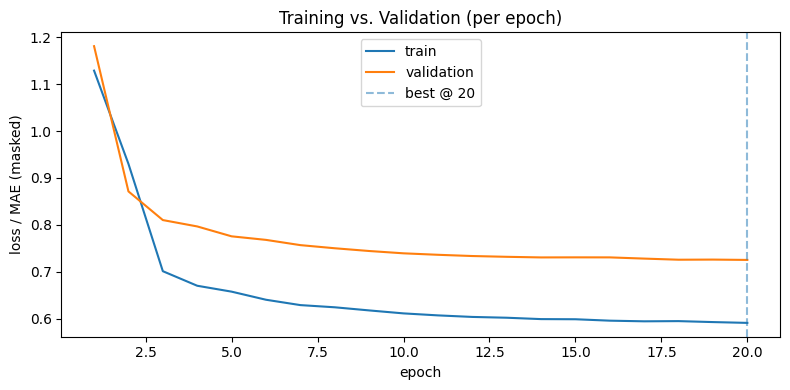

[1.1289525847434998, 0.930114520072937, 0.7012125284671783, 0.6701776242256164, 0.6575875844955444, 0.6403240630626679, 0.628899744272232, 0.6242408056259156, 0.6175670322179795, 0.6112267270088195, 0.6069797694683075, 0.6036739139556885, 0.6019739151000977, 0.5990387318134308, 0.5987277872562409, 0.5957017395496368, 0.594327983379364, 0.594746577501297, 0.5926908941268921, 0.5909738824367523]


In [9]:
import numpy as np
import matplotlib.pyplot as plt

h = getattr(gnn, "history", None)
if not h:
    raise RuntimeError("No history found. Re-run training to populate model.history.")

epochs = np.array(h["epoch"])
train  = np.array(h["train"])
val    = np.array(h["val"])
best_ix = int(np.argmin(val))

plt.figure(figsize=(8,4))
plt.plot(epochs, train, label="train")
plt.plot(epochs, val,   label="validation")
plt.axvline(epochs[best_ix], linestyle="--", alpha=0.5, label=f"best @ {epochs[best_ix]}")
plt.title("Training vs. Validation (per epoch)")
plt.xlabel("epoch")
plt.ylabel("loss / MAE (masked)")
plt.legend()
plt.tight_layout()
plt.show()

print(h["train"])


In [10]:
# Rebuild exog for the full timeline if needed (above already computed for full T)
Xhat_gnn = rollout_over_timeline(gnn, X, M, exog, cfg.H_in, cfg.H_out, cfg.device)  # [T,E]  :contentReference[oaicite:25]{index=25}


In [11]:
import numpy as np
import pandas as pd

def make_df_pred(times, X, M, preds, net_cfg, model_name="gnn"):
    """
    times: DatetimeIndex of length T
    X:      [T,E] true counts
    M:      [T,E] mask (1 if observed)
    preds:  [T,E] predictions aligned to times (next-step rollout)
    net_cfg: holds directed_edges, edge_index, etc.
    """
    times = pd.DatetimeIndex(times)
    T, E = X.shape
    assert preds.shape == (T, E), f"preds shape {preds.shape} != {(T,E)}"

    edges = list(net_cfg.directed_edges)  # [(u,v), ...]
    u = np.array([e[0] for e in edges])
    v = np.array([e[1] for e in edges])

    # tile edge columns over time
    df = pd.DataFrame({
        "timestamp": np.repeat(times.values, E),
        "u": np.tile(u, T),
        "v": np.tile(v, T),
        "true": X.reshape(-1),
        "pred": preds.reshape(-1),
        "observed": (M.reshape(-1) > 0.5),
        "h": 0,                     # one-step horizon (see note below)
        "model": model_name,
    })
    df["edge"] = df["u"].astype(str) + "->" + df["v"].astype(str)
    # ensure timestamp is datetime64[ns] (keep tz if present)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df

# Example: build it for the ST-GNN predictions
df_pred = make_df_pred(times, X, M, Xhat_gnn, net_cfg, model_name="stgnn")

In [12]:
# Evaluate GNN on test loader via your evaluate()
test_metrics = evaluate_loader(gnn, loaders["test"], cfg.device)   # {'MAE':..., 'RMSE':...}  :contentReference[oaicite:26]{index=26}
test_metrics


{'MAE': 0.694393376156645, 'RMSE': 2.2016525190962097}

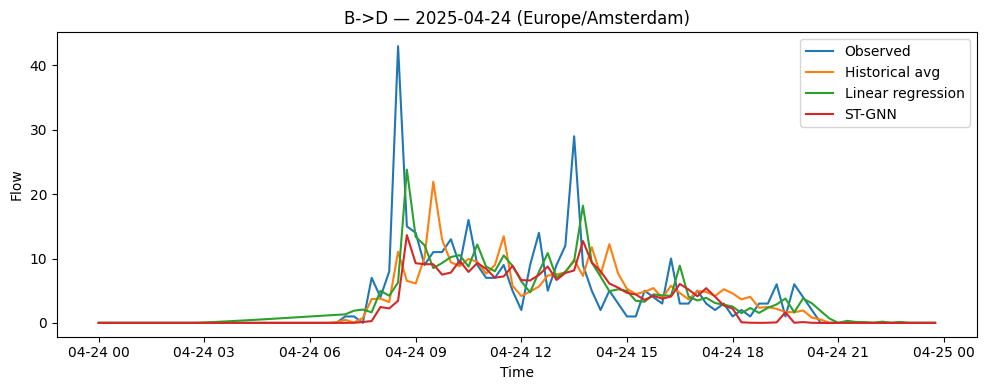

In [13]:
from zoneinfo import ZoneInfo

# --- choose edge + day ---
edge_uv = ('B', 'D')        # change me
day_str = '2025-04-24'      # change me

u, v = edge_uv
edge_label = f'{u}->{v}'

# map (u,v) -> edge index
edge_map = getattr(net_cfg, 'edge_index', None) or getattr(net_cfg, 'index_edge', None)
if not edge_map:
    edge_map = {e: i for i, e in enumerate(net_cfg.directed_edges)}
edge_i = edge_map.get((u, v))
if edge_i is None:
    raise KeyError(f'Edge {edge_label} not found.')

# --- timezone: Europe/Amsterdam ---
AMS = ZoneInfo('Europe/Amsterdam')

# make a tz-aware "day start" in Amsterdam time
day0 = pd.Timestamp(day_str, tz=AMS).normalize()

# ensure `times` is also in Amsterdam time (localize if naive, else convert)
times_ams = (times.tz_localize('UTC').tz_convert(AMS)
             if getattr(times, 'tz', None) is None
             else times.tz_convert(AMS))

# build 1-day mask
mask = (times_ams >= day0) & (times_ams < day0 + pd.Timedelta('1D'))
if not mask.any():
    raise ValueError(f'No samples on {day0.date()} (range: {times_ams.min().date()} → {times_ams.max().date()}).')

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_ams[mask], X[mask, edge_i],             label='Observed')
ax.plot(times_ams[mask], Xhat_baseline[mask, edge_i], label='Historical avg')
ax.plot(times_ams[mask], Xhat_reg[mask, edge_i],      label='Linear regression')
ax.plot(times_ams[mask], Xhat_gnn[mask, edge_i],      label='ST-GNN')
ax.set(title=f'{edge_label} — {day0.date()} (Europe/Amsterdam)', xlabel='Time', ylabel='Flow')
ax.legend(); fig.tight_layout(); plt.show()


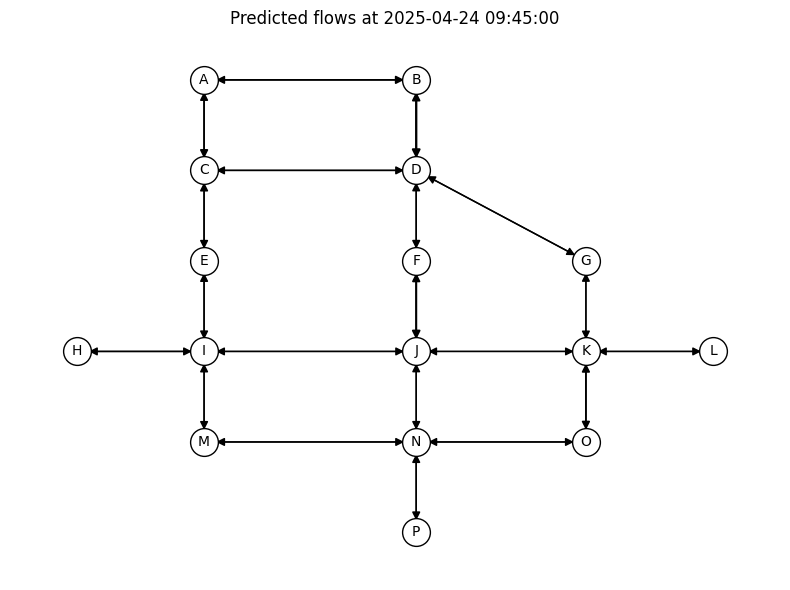

In [19]:
# Build edge->value mapping for a chosen timestamp (e.g., mid-day in test)
t_idx = int(np.where(mask)[0].mean())
edge_values = { net_cfg.index_edge[i] if hasattr(net_cfg, "index_edge") and net_cfg.index_edge
                else net_cfg.directed_edges[i]: float(Xhat_gnn[t_idx, i]) for i in range(E) }
VIZ.draw_network_flows(edge_values, net_cfg, title=f'Predicted flows at {times[t_idx]}')  # :contentReference[oaicite:27]{index=27}


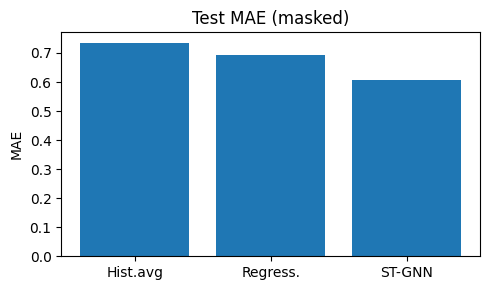

In [15]:
# Compute MAE over the test slice for each model, masking like your training
sl = splits["test"]
def masked_mae_np(yhat, y, m):
    num = np.abs(yhat - y) * m
    return float(num.sum() / np.clip(m.sum(), 1.0, None))

mae_baseline = masked_mae_np(Xhat_baseline[sl], X[sl], M[sl])
mae_reg      = masked_mae_np(Xhat_reg[sl],      X[sl], M[sl])
# For the GNN, use timeline rollout for apples-to-apples aggregation
mae_gnn      = masked_mae_np(Xhat_gnn[sl],      X[sl], M[sl])

plt.figure(figsize=(5,3))
plt.bar(['Hist.avg','Regress.','ST-GNN'], [mae_baseline, mae_reg, mae_gnn])
plt.ylabel('MAE')
plt.title('Test MAE (masked)')
plt.tight_layout(); plt.show()


In [30]:
import networkx as nx
import matplotlib.colors as mcolors
import matplotlib.cm as cm

def _select_by_h(df_edge_time, use_closest=True):
    if use_closest:
        return (df_edge_time.sort_values(['timestamp','h'])
                           .drop_duplicates(['timestamp','edge'], keep='first'))
    else:
        return (df_edge_time.sort_values(['timestamp','h'])
                           .drop_duplicates(['timestamp','edge'], keep='last'))

def _mae_rmse_on_observed(df_edge_day):
    g = df_edge_day[df_edge_day['observed']]
    if g.empty:
        return np.nan, np.nan
    err = g['pred'] - g['true']
    mae = np.abs(err).mean()
    rmse = np.sqrt((err**2).mean())
    return mae, rmse

def _edge_peak_tables(df_day_sel: pd.DataFrame) -> pd.DataFrame:
    # 0) ensure 'edge' column exists (fallback from u/v)
    if 'edge' not in df_day_sel.columns:
        df_day_sel = df_day_sel.copy()
        df_day_sel['edge'] = df_day_sel['u'].astype(str) + '->' + df_day_sel['v'].astype(str)

    # 1) TRUE peaks (use observed bins only)
    obs = df_day_sel[df_day_sel.get('observed', True)].copy()

    if obs.empty:
        # build an empty but correctly-typed table
        cols = ['edge','u','v','peak_true','t_true_peak','pred_at_true_peak',
                'abs_err_at_true_peak','peak_pred','t_pred_peak','true_at_pred_peak',
                'abs_err_at_pred_peak','mae_day','rmse_day','observed_bins','total_bins','observed_frac']
        return pd.DataFrame(columns=cols)

    obs_sorted = obs.sort_values(['edge','true'], ascending=[True, False])
    true_peaks = (obs_sorted.groupby('edge', as_index=False)
                           .first()[['edge','u','v','timestamp','true']]
                           .rename(columns={'timestamp':'t_true_peak','true':'peak_true'}))

    # predicted value at the time of the TRUE peak
    pred_at_true_peak = (df_day_sel[['edge','timestamp','pred']]
                         .merge(true_peaks[['edge','t_true_peak']],
                                left_on=['edge','timestamp'],
                                right_on=['edge','t_true_peak'],
                                how='right')
                         .rename(columns={'pred':'pred_at_true_peak'})
                         [['edge','pred_at_true_peak']])

    # 2) PRED peaks (on selected horizon rows)
    sel_sorted = df_day_sel.sort_values(['edge','pred'], ascending=[True, False])
    pred_peaks = (sel_sorted.groupby('edge', as_index=False)
                           .first()[['edge','timestamp','pred','true','observed']]
                           .rename(columns={'timestamp':'t_pred_peak','pred':'peak_pred',
                                            'true':'true_at_pred_peak','observed':'obs_at_pred_peak'}))

    # 3) Per-edge day stats (MAE/RMSE on observed bins only)
    stats_rows = []
    for e, g in df_day_sel.groupby('edge'):
        g_obs = g[g.get('observed', True)]
        if g_obs.empty:
            mae = rmse = np.nan
            obs_cnt = 0
        else:
            err = (g_obs['pred'] - g_obs['true']).to_numpy()
            mae = np.abs(err).mean()
            rmse = np.sqrt((err**2).mean())
            obs_cnt = int(g_obs.shape[0])
        tot_cnt = int(g.shape[0])
        stats_rows.append({
            'edge': e, 'mae_day': mae, 'rmse_day': rmse,
            'observed_bins': obs_cnt, 'total_bins': tot_cnt,
            'observed_frac': (obs_cnt / max(1, tot_cnt))
        })
    day_stats = pd.DataFrame(stats_rows)

    # 4) Join everything on a *column* 'edge'
    tbl = (true_peaks
           .merge(pred_at_true_peak, on='edge', how='left')
           .merge(pred_peaks,       on='edge', how='left')
           .merge(day_stats,        on='edge', how='left'))

    # 5) Absolute errors at peak times
    tbl['abs_err_at_true_peak'] = (tbl['pred_at_true_peak'] - tbl['peak_true']).abs()
    tbl['abs_err_at_pred_peak'] = (tbl['peak_pred'] - tbl['true_at_pred_peak']).abs()

    # nice ordering
    cols = ['edge','u','v','peak_true','t_true_peak','pred_at_true_peak','abs_err_at_true_peak',
            'peak_pred','t_pred_peak','true_at_pred_peak','abs_err_at_pred_peak',
            'mae_day','rmse_day','observed_bins','total_bins','observed_frac']
    return tbl[cols].sort_values('peak_true', ascending=False).reset_index(drop=True)



def _plot_network_values(POS, edges, values, title, vmin=None, vmax=None, cmapname='viridis', show_arrows=True, ax=None):
    if ax is None: ax = plt.gca()
    G = nx.DiGraph(); G.add_nodes_from(POS.keys()); G.add_edges_from(edges)
    edgelist = list(edges)

    vals = np.array([values.get((u,v), np.nan) for (u,v) in edgelist], float)
    # choose scale
    if vmin is None: vmin = float(np.nanmin(vals)) if np.isfinite(vals).any() else 0.0
    if vmax is None: vmax = float(np.nanmax(vals)) if np.isfinite(vals).any() else 1.0
    if not np.isfinite(vmin): vmin = 0.0
    if (not np.isfinite(vmax)) or vmax <= vmin: vmax = vmin + 1.0

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.get_cmap(cmapname)
    # colors: NaNs -> light gray
    colors = [cmap(norm(v)) if np.isfinite(v) else (0.85,0.85,0.85,1.0) for v in vals]
    # # widths: based on |value| so negatives still visible (error panel)
    # scale = vmax - vmin if vmax > vmin else 1.0
    # widths = 1.0 + 4.0 * (np.abs(vals - (vmin + scale/2.0)) / (scale/2.0))
    # widths = np.clip(widths, 0.5, 5.0)
    widths = np.full_like(vals, 2.0, dtype=float)


    ax.set_title(title)
    nx.draw_networkx_nodes(G, POS, node_size=300, node_color='lightgray', edgecolors='k', linewidths=0.5, ax=ax)
    nx.draw_networkx_edges(G, POS, edgelist=edgelist, width=widths,
                           edge_color=colors, arrows=show_arrows,
                           arrowstyle='-|>', arrowsize=10, ax=ax)
    nx.draw_networkx_labels(G, POS, font_size=9, ax=ax)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    ax.figure.colorbar(sm, ax=ax, shrink=0.75).set_label('value')
    ax.set_axis_off()
    return sm

C:\Users\raf\AppData\Local\Temp\ipykernel_20348\1022905746.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmapname)


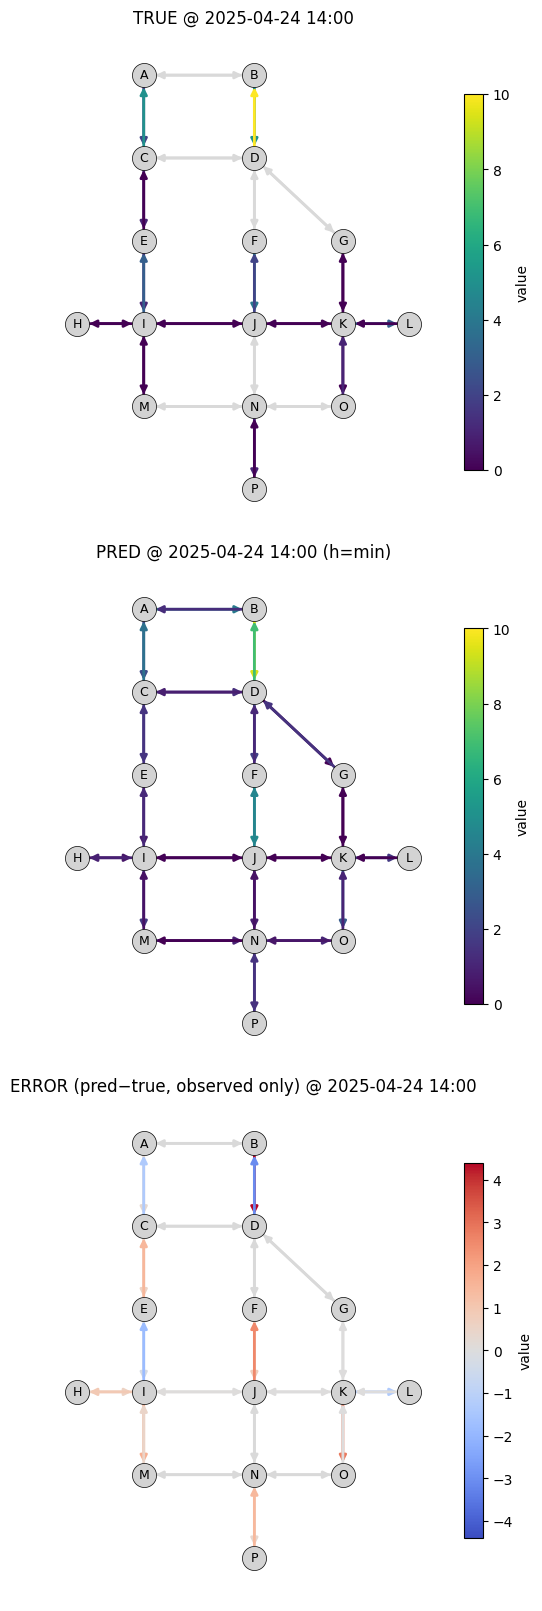

In [34]:
# === Moment snapshot per directed edge (TRUE / PRED / ERROR) ===
# Requirements in scope: df_pred with columns ['timestamp','u','v','true','pred','observed', 'h' (optional)],
#                        POS, DIRECTED_EDGES, and the helpers: _select_by_h, _plot_network_values

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from zoneinfo import ZoneInfo

# ------- choose the moment -------
# Option A: set local Amsterdam day+time directly
day_str  = '2025-04-24'    # change me
time_str = '14:00'         # change me

# Option B (alternative): if the old notebook stored UTC clock time, set it here and we'll convert
prev_notebook_time_utc = None   # e.g. '2025-04-24 10:00'  (leave as None if using A)

use_closest = True  # if the exact bin isn't present, pick nearest within the day

AMS = ZoneInfo('Europe/Amsterdam')

# --- normalize timestamps to Amsterdam time for selection/labels ---
ts = df_pred['timestamp']
ts_ams = (ts.dt.tz_localize('UTC').dt.tz_convert(AMS)) if ts.dt.tz is None else ts.dt.tz_convert(AMS)

if prev_notebook_time_utc:
    # old notebook moment (UTC) -> Amsterdam moment
    t_req_ams = pd.Timestamp(prev_notebook_time_utc, tz='UTC').tz_convert(AMS)
else:
    t_req_ams = pd.Timestamp(f"{day_str} {time_str}", tz=AMS)

# filter to the same local day
df_day = df_pred[ts_ams.dt.date == t_req_ams.date()].copy()
if df_day.empty:
    raise ValueError(f"No predictions for local day {t_req_ams.date()} in df_pred.")

# resolve horizon duplicates first
df_day = _select_by_h(df_day, use_closest=use_closest)

# choose the bin at/nearest to the requested time (within that day)
ts_ams_day = ts_ams.loc[df_day.index]
if (ts_ams_day == t_req_ams).any():
    t_sel_ams = t_req_ams
else:
    # nearest within the day
    diffs = np.abs(ts_ams_day.values.astype('datetime64[ns]') - t_req_ams.to_datetime64())
    t_sel_ams = pd.Timestamp(ts_ams_day.values[int(np.argmin(diffs))]).tz_convert(AMS)
    if use_closest:
        print(f"Using closest timestamp on {t_req_ams.date()}: requested {t_req_ams.time()},"
              f" selected {t_sel_ams.time()}")

# rows at the selected moment (in original df timezone)
df_t = df_day.loc[ts_ams_day == t_sel_ams].copy()
if 'edge' not in df_t.columns:
    df_t['edge'] = df_t['u'].astype(str) + '->' + df_t['v'].astype(str)

# --- build per-edge dicts for plotting at that moment ---
edge_true, edge_pred, edge_err = {}, {}, {}
for (u, v), g in df_t.groupby(['u', 'v']):
    pred = float(g['pred'].iloc[0]); edge_pred[(u, v)] = pred
    if bool(g['observed'].iloc[0]):
        tru = float(g['true'].iloc[0])
    else:
        tru = np.nan
    edge_true[(u, v)] = tru
    edge_err[(u, v)]  = (pred - tru) if np.isfinite(tru) else np.nan

# common scales
vmax_tp = max(1.0, np.nanmax([*edge_true.values(), *edge_pred.values(), 1.0]))
err_vals = np.array([v for v in edge_err.values() if np.isfinite(v)])
err_max  = float(np.nanmax(np.abs(err_vals))) if err_vals.size else 1.0

# --- plot three panels (vertical like your previous notebook) ---
fig, axs = plt.subplots(3, 1, figsize=(5, 16), constrained_layout=True)
_plot_network_values(POS, DIRECTED_EDGES, edge_true,
                     f"TRUE @ {t_sel_ams.strftime('%Y-%m-%d %H:%M')}",
                     vmin=0, vmax=vmax_tp, cmapname='viridis', ax=axs[0])
_plot_network_values(POS, DIRECTED_EDGES, edge_pred,
                     f"PRED @ {t_sel_ams.strftime('%Y-%m-%d %H:%M')} (h={'min' if use_closest else 'max'})",
                     vmin=0, vmax=vmax_tp, cmapname='viridis', ax=axs[1])
_plot_network_values(POS, DIRECTED_EDGES, edge_err,
                     f"ERROR (pred−true, observed only) @ {t_sel_ams.strftime('%Y-%m-%d %H:%M')}",
                     vmin=-err_max, vmax=err_max, cmapname='coolwarm', ax=axs[2])
plt.show()
